In [40]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# !pip install pingouin
import pingouin as pg
from statsmodels.tsa.stattools import acf

import importlib
import backtester
importlib.reload(backtester)

from backtester import Strategy
# import Ruff
# import Black
# import MyPy

In [3]:
### Current Tickers ###
mineral_stocks = [
    'GC=F',  # Gold
    'HG=F',  # Copper
    'PA=F',  # Palladium
    'PL=F',  # Platinum
    'SI=F',  # Silver
]

growth_stocks = [
    "NVDA",  # NVIDIA Corporation
    "MRVL",  # Marvell Technology Inc.
    "FTNT",  # Fortinet Inc.
    "AMD",   # Advanced Micro Devices, Inc.
    "CRM",   # Salesforce Inc.
    "ADBE",  # Adobe Inc.
    "ZM",    # Zoom Video Communications Inc.
    "SHOP",  # Shopify Inc.
    "SNAP",  # Snap Inc.
    "NET",   # Cloudflare, Inc.
    "TWLO",  # Twilio Inc.
    "MDB",   # MongoDB, Inc.
    "RBLX",  # Roblox Corporation
    "SNOW",  # Snowflake Inc.
    "PINS",  # Pinterest Inc.
    "TTD",   # The Trade Desk
    "DOCU",  # DocuSign, Inc.
    'SLAB',  # Silicon Laboratories Inc.
]

value_stocks = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "INTC",  # Intel Corporation
    "IBM",   # International Business Machines Corporation
    "ORCL",  # Oracle Corporation
    "CSCO",  # Cisco Systems, Inc.
    "HPE",   # Hewlett Packard Enterprise Co.
    "QCOM",  # Qualcomm Incorporated
    "TXN",   # Texas Instruments Incorporated
    "AVGO",  # Broadcom Inc.
    "MU",    # Micron Technology Inc.
    "LRCX",  # Lam Research Corporation
    "STX",   # Seagate Technology Holdings PLC
    "WDC",   # Western Digital Corporation
    "ADI",   # Analog Devices, Inc.
    "AMAT",  # Applied Materials, Inc.
    "MSI",   # Motorola Solutions, Inc.
    "VZ",    # Verizon Communications Inc.
    "TMUS"   # T-Mobile US, Inc.
]

market_indices = [
    "^DJI",     # Dow Jones Industrial Average (United States)
    "^GSPC",    # S&P 500 (United States)
    "^IXIC",    # NASDAQ Composite (United States)
    "^N225",    # Nikkei 225 (Japan)
    "^FTSE",    # FTSE 100 (United Kingdom)
    "^GDAXI",   # DAX (Germany)
    "^FCHI",    # CAC 40 (France)
    "000001.SS",# Shanghai Composite Index (China)
    "^BSESN",   # SENSEX (India)
    "^NSEI",    # Nifty 50 (India)
    "^KS11",    # KOSPI (South Korea)
    "^AORD",    # All Ordinaries (Australia)
    "^BVSP",    # Bovespa (Brazil)
    "^MERV",    # MERVAL (Argentina)
    "^TWII",    # TAIEX (Taiwan)
    "^STI",     # Straits Times Index (Singapore)
    "^JKSE",    # Jakarta Composite Index (Indonesia)
]


In [4]:
start_date = "2020-01-01"


### Download Mineral Data ###
minerals = yf.download(mineral_stocks,start=start_date,auto_adjust=True)[["Close","Volume"]]
minerals = minerals.dropna()
minerals.columns = [(x[1] +' '+ x[0]).strip() for x in minerals.columns.to_list()]

### Create time stamp columns ###
minerals['Year'] = minerals.index.year
minerals['Month'] = minerals.index.month
minerals['Month Name'] = minerals.index.month_name()
minerals['Day'] = minerals.index.day


## Download Closing Price of Growth and Value Stocks in One DataFrame ###
all_stocks = growth_stocks + value_stocks
stock_data = yf.download(all_stocks, start=start_date,auto_adjust=True, progress=False)['Close']

## worldwide markets
worldwide_markets = yf.download(market_indices, start=start_date,auto_adjust=True, progress=False)['Close']

[*********************100%***********************]  5 of 5 completed


# Backtesting

* example strategy: buy Gold when 20 day moving average > 60 day moving average
* backtest: check Gold's prices in the past and trade under condition
* results: show if the trades were profitable

In [ ]:
data = minerals.loc[:,['GC=F Close']]

In [ ]:
strategy = Strategy(
    indicators={
        "sma_20": lambda df: df["GC=F Close"].rolling(window=20).mean(),
        "sma_60": lambda df: df['GC=F Close'].rolling(window=60).mean() 
    },
    signal_logic=lambda row: 1 if row['sma_20'] > row['sma_60'] else -1
)

data = strategy.generate_signals(data)

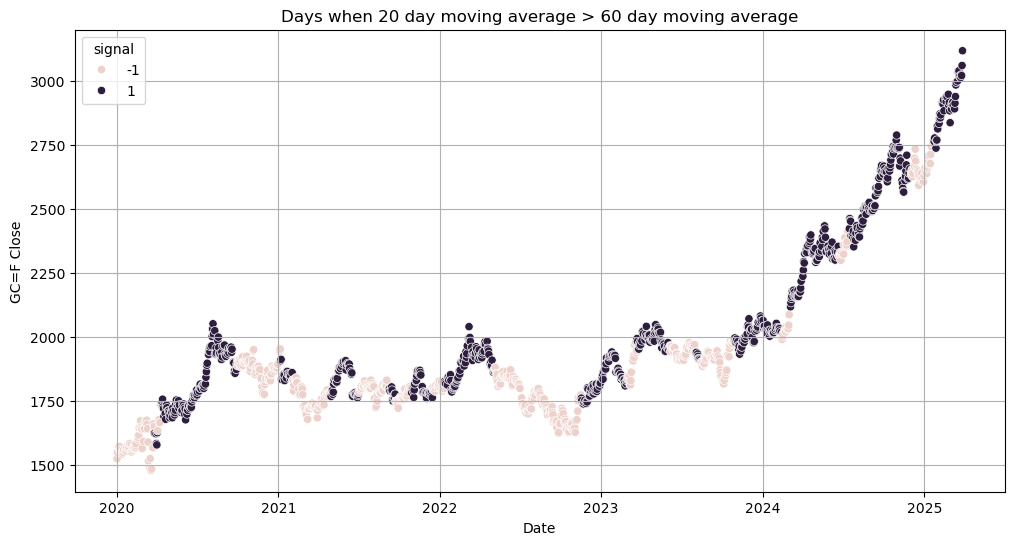

In [60]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=data,x=data.index,y='GC=F Close',hue='signal')
plt.title("Days when 20 day moving average > 60 day moving average")
plt.grid(True)
plt.show()